In [1]:
import pandas as pd


In [6]:
import os




print(os.listdir())

['.config', 'sample_data']


In [7]:
df = pd.read_excel("/data.csv.xlsx")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,13:08:00,Ewallet,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-05-02,10:29:00,Cash,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-05-03,13:23:00,Credit card,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-05-04,20:33:00,Ewallet,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-05-05,10:37:00,Ewallet,30.2085,5.3


In [8]:
print(df.head())
print(df.columns)

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715 2019-05-01   
1  Electronic accessories       15.28         5   3.8200   80.2200 2019-05-02   
2      Home and lifestyle       46.33         7  16.2155  340.5255 2019-05-03   
3       Health and beauty       58.22         8  23.2880  489.0480 2019-05-04   
4       Sports and travel       86.31         7  30.2085  634.3785 2019-05-05   

       Time      Payment  gross income  Rating  
0  13:08:00      Ewallet       26.1415     9.1  
1  10:29:00         Cash        3.8200     9.6  
2  13:23:00  Cred

In [9]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     1000 non-null   object        
 1   Branch         1000 non-null   object        
 2   City           1000 non-null   object        
 3   Customer type  1000 non-null   object        
 4   Gender         1000 non-null   object        
 5   Product line   1000 non-null   object        
 6   Unit price     1000 non-null   float64       
 7   Quantity       1000 non-null   int64         
 8   Tax 5%         1000 non-null   float64       
 9   Total          1000 non-null   float64       
 10  Date           1000 non-null   datetime64[ns]
 11  Time           1000 non-null   object        
 12  Payment        1000 non-null   object        
 13  gross income   1000 non-null   float64       
 14  Rating         1000 non-null   float64       
dtypes: datetime64[ns](1), 

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'gross income', 'Rating'],
      dtype='object')

In [10]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,13:08:00,Ewallet,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-05-02,10:29:00,Cash,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-05-03,13:23:00,Credit card,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-05-04,20:33:00,Ewallet,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-05-05,10:37:00,Ewallet,30.2085,5.3


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Unit price', 'Quantity']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [12]:
predictions = model.predict(X_test)

print(predictions[:10])

[509.5146078  600.95868184 407.96594901 101.70754226 -78.87242053
 602.06029381 147.24792969 662.72821025 478.1843573  121.59967774]


In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.9042708171993606
MAE: 58.53704658032449


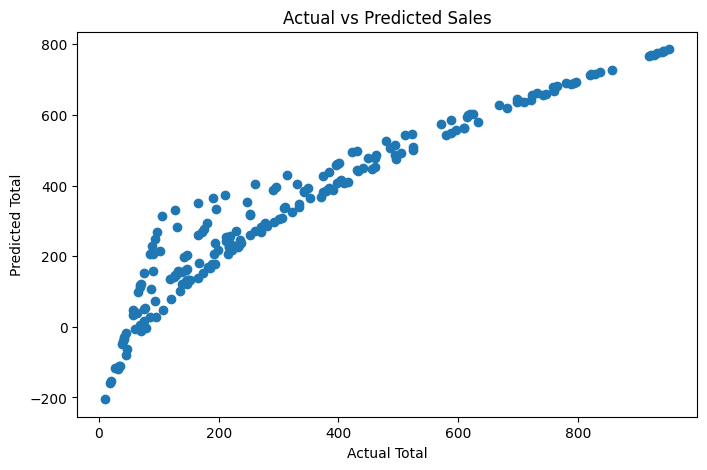

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Total")
plt.ylabel("Predicted Total")
plt.title("Actual vs Predicted Sales")
plt.savefig("prediction_graph.png")
plt.show()

In [15]:
future_data = [[50, 8]]  # Unit Price=50, Quantity=8

future_prediction = model.predict(future_data)

print("Predicted Total Sales:", future_prediction[0])

Predicted Total Sales: 433.6824616858325


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
